# Danish Vehicle Registration — Time Series Plot

Training data: 2018-Jan to 2023-Dec (total registered vehicles vs. decimal year).

In [11]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1

In [12]:
# Read CSV and filter for training period (2018-Jan to 2023-Dec)
df = pd.read_csv("DST_BIL54.csv")
df["time"] = pd.to_datetime(df["time"], format="%Y-%m")

start = pd.Timestamp("2018-01-01")
end = pd.Timestamp("2023-12-01")
train = df[(df["time"] >= start) & (df["time"] <= end)].copy()

# Create time variable x as decimal year: 2018-Jan -> 2018.0, 2018-Feb -> 2018 + 1/12, ...
# Formula: x = year + (month - 1) / 12
train["x"] = train["time"].dt.year + (train["time"].dt.month - 1) / 12

# Use total (number of registered vehicles) and x for plotting
x = train["x"].values
total = train["total"].values
print(f"Training period: {train['time'].min().strftime('%Y-%b')} to {train['time'].max().strftime('%Y-%b')} ({len(train)} months)")
train[["time", "x", "total"]].head(12)

Training period: 2018-jan to 2023-dec (72 months)


,time,x,total
0,2018-01-01,2018.000000,2930483
1,2018-02-01,2018.083333,2934044
2,2018-03-01,2018.166667,2941422
3,2018-04-01,2018.250000,2951498
4,2018-05-01,2018.333333,2963093
5,2018-06-01,2018.416667,2973721
6,2018-07-01,2018.500000,2976096
7,2018-08-01,2018.583333,2985537
8,2018-09-01,2018.666667,2983209
9,2018-10-01,2018.750000,2982473


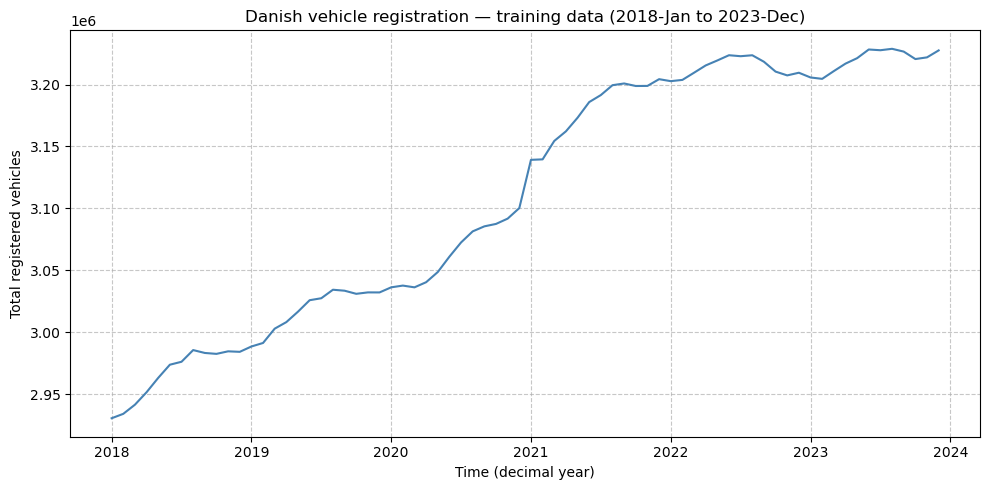

In [13]:
# Time series plot: total registered vehicles vs. decimal year x
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, total, color="steelblue", linewidth=1.5)
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("Total registered vehicles")
ax.set_title("Danish vehicle registration — training data (2018-Jan to 2023-Dec)")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Total Registered Vehicles is increasing troughout the entire period from 2018-2024

# 2

In [14]:
# print first 3 time points in train
print(train.head(3))

        time    total  gasoline   diesel  fgas  ngas  electricity  petroleum  \
0 2018-01-01  2930483   1781826  1136656    12   256         9304          0   
1 2018-02-01  2934044   1783338  1138414    12   255         9343          0   
2 2018-03-01  2941422   1787219  1141576    12   257         9399          0   

   hydrogen  methanol  ethanol  pluginhybrid  otherfuels            x  
0        81         0        0          2340           8  2018.000000  
1        80         0        0          2593           9  2018.083333  
2        77         0        0          2873           9  2018.166667  


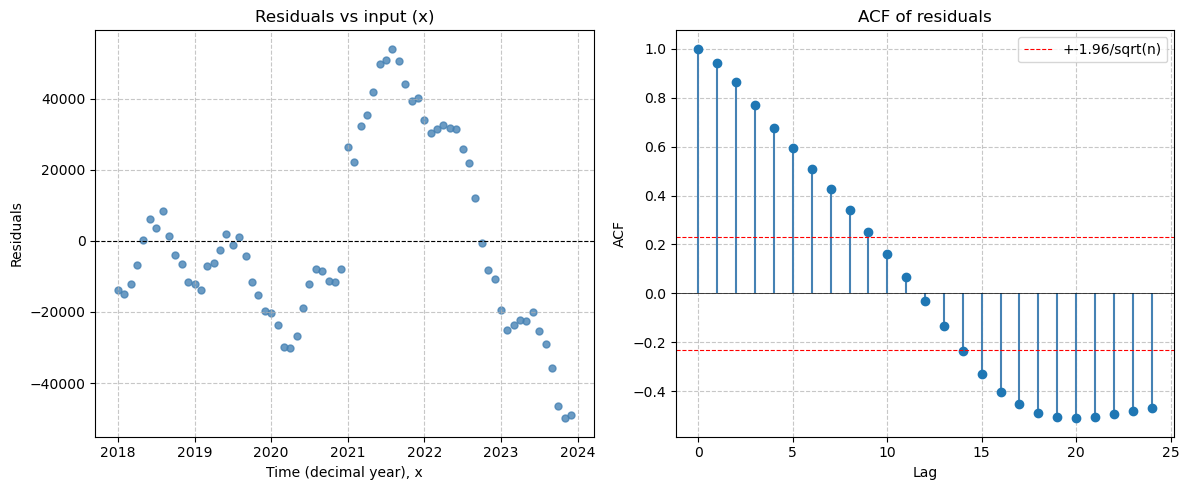

In [15]:
# Residual diagnostics: residuals vs input, ACF of residuals
# Safety guard: this notebook section appears before OLS in your current order.
# If residuals are not available yet, compute OLS pieces from train data here.
if 'residuals' not in globals():
    # Build linear-trend design matrix X = [1, x] and target y from train set
    x_vals = train['x'].values
    y_vals = train['total'].values
    X = np.column_stack([np.ones(len(train)), x_vals])
    y = y_vals.reshape(-1, 1)

    # OLS estimate and fitted values
    theta_hat = np.linalg.solve(X.T @ X, X.T @ y)
    y_fitted = X @ theta_hat

    # Residual vector used for diagnostics below
    residuals = y - y_fitted

res_flat = residuals.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) Scatter: residuals vs input (x)
ax1 = axes[0]
ax1.scatter(x_vals, res_flat, color='steelblue', s=25, alpha=0.8)
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Time (decimal year), x')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs input (x)')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2) ACF of residuals (sample autocorrelation)
max_lag = min(24, len(res_flat) // 2 - 1)
res_centered = res_flat - res_flat.mean()
c0 = np.sum(res_centered ** 2)
acf_vals = np.array([1.0] + [np.sum(res_centered[:-k] * res_centered[k:]) / c0 for k in range(1, max_lag + 1)])
lags = np.arange(len(acf_vals))
ax2 = axes[1]
ax2.stem(lags, acf_vals, basefmt=' ', linefmt='steelblue', markerfmt='o')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axhline(1.96 / np.sqrt(len(res_flat)), color='red', linestyle='--', linewidth=0.8, label='+-1.96/sqrt(n)')
ax2.axhline(-1.96 / np.sqrt(len(res_flat)), color='red', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Lag')
ax2.set_ylabel('ACF')
ax2.set_title('ACF of residuals')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# 3

In [16]:
# Estimate θ₁ and θ₂ by OLS: θ̂ = (X'X)^{-1} X'y
# Full training set: design matrix X (column of 1s, column of x) and output y (total)
N = len(train)
ones = np.ones(N)
x_vals = train["x"].values
y_vals = train["total"].values

X = np.column_stack([ones, x_vals])  # N x 2
y = y_vals.reshape(-1, 1)           # N x 1

# OLS: θ̂ = (X'X)^{-1} X'y
XtX = X.T @ X
Xty = X.T @ y
theta_hat = np.linalg.solve(XtX, Xty)

theta1 = theta_hat[0, 0]   # intercept
theta2 = theta_hat[1, 0]   # slope (vehicles per year)

print("Linear trend model: Y_t = θ₁ + θ₂·x_t + ε_t")
print(f"Estimated θ₁ (intercept): {theta1:,.2f}")
print(f"Estimated θ₂ (slope):    {theta2:,.2f}")
print(f"\nInterpretation: total ≈ {theta1:,.0f} + {theta2:,.0f} × (decimal year)")

Linear trend model: Y_t = θ₁ + θ₂·x_t + ε_t
Estimated θ₁ (intercept): -110,355,428.09
Estimated θ₂ (slope):    56,144.56

Interpretation: total ≈ -110,355,428 + 56,145 × (decimal year)


Parameter estimates and estimated standard errors:
──────────────────────────────────────────────────
  θ̂₁ = -110,355,428.09   σ̂_θ̂₁ = 3,593,581.12
  θ̂₂ =      56,144.56   σ̂_θ̂₂ =     1,778.16
──────────────────────────────────────────────────


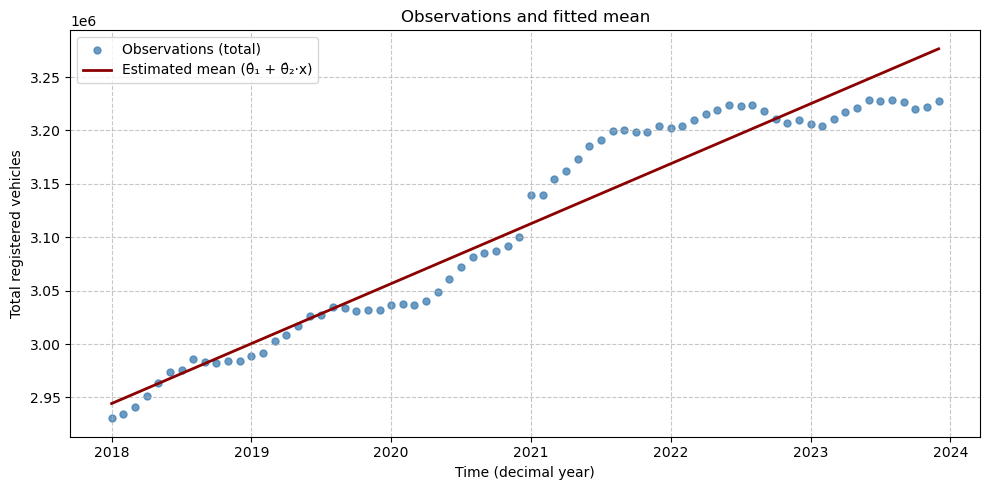

In [17]:
# Standard errors: σ̂² = RSS/(N-p), Cov(θ̂) = σ̂² (X'X)^{-1}, SE(θ̂_j) = sqrt(Cov(θ̂)_jj)
p = 2
y_fitted = X @ theta_hat
residuals = y - y_fitted
RSS = (residuals ** 2).sum()
sigma2_hat = RSS / (N - p)
XtX_inv = np.linalg.inv(XtX)
cov_theta = sigma2_hat * XtX_inv
se_theta1 = np.sqrt(cov_theta[0, 0])
se_theta2 = np.sqrt(cov_theta[1, 1])

print("Parameter estimates and estimated standard errors:")
print("─" * 50)
print(f"  θ̂₁ = {theta1:>14,.2f}   σ̂_θ̂₁ = {se_theta1:>12,.2f}")
print(f"  θ̂₂ = {theta2:>14,.2f}   σ̂_θ̂₂ = {se_theta2:>12,.2f}")
print("─" * 50)

# Plot: observations as points, estimated mean as line
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_vals, y_vals, color="steelblue", s=25, alpha=0.8, label="Observations (total)")
ax.plot(x_vals, y_fitted, color="darkred", linewidth=2, label="Estimated mean (θ̂₁ + θ̂₂·x)")
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("Total registered vehicles")
ax.set_title("Observations and fitted mean")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
# Forecast for test set: 2024-Jan to 2024-Dec (12 months)
# Point forecast: ŷ = θ̂₁ + θ̂₂·x
# 95% prediction interval: ŷ ± t_{N-2, 0.975} × SE_pred, with SE_pred = σ̂ × sqrt(1 + x_new'(X'X)^{-1} x_new)
from scipy import stats

# Test period: 12 months from 2024-Jan to 2024-Dec
test_months = pd.date_range("2024-01-01", periods=12, freq="MS")
x_test = np.array([2024 + (i - 1) / 12 for i in range(1, 13)])  # 2024.0, 2024.083, ..., 2024.917
X_test = np.column_stack([np.ones(12), x_test])

# Point forecasts
y_pred = (X_test @ theta_hat).flatten()

# Prediction standard error: SE_pred_t = σ̂ × sqrt(1 + x_t'(X'X)^{-1} x_t)
sigma_hat = np.sqrt(sigma2_hat)
se_pred = np.array([
    sigma_hat * np.sqrt(1 + X_test[i : i + 1] @ XtX_inv @ X_test[i : i + 1].T).item()
    for i in range(12)
])

# 95% prediction interval (t with N-2 df)
t_crit = stats.t.ppf(0.975, N - p)
lower = y_pred - t_crit * se_pred
upper = y_pred + t_crit * se_pred

# Table: Month, x, Predicted, Lower 95% PI, Upper 95% PI
forecast_df = pd.DataFrame({
    "Month": [d.strftime("%Y-%b") for d in test_months],
    "x": np.round(x_test, 3),
    "Predicted": np.round(y_pred, 0),
    "Lower 95% PI": np.round(lower, 0),
    "Upper 95% PI": np.round(upper, 0),
})
print("Forecasts and 95% prediction intervals (test set: 2024-Jan to 2024-Dec)\n")
display(forecast_df)

Forecasts and 95% prediction intervals (test set: 2024-Jan to 2024-Dec)



,Month,x,Predicted,Lower 95% PI,Upper 95% PI
0,2024-jan,2024.000,3281154.0,3227579.0,3334728.0
1,2024-feb,2024.083,3285832.0,3232198.0,3339467.0
2,2024-mar,2024.167,3290511.0,3236815.0,3344208.0
3,2024-apr,2024.250,3295190.0,3241430.0,3348950.0
4,2024-maj,2024.333,3299869.0,3246044.0,3353693.0
5,2024-jun,2024.417,3304547.0,3250656.0,3358439.0
6,2024-jul,2024.500,3309226.0,3255267.0,3363185.0
7,2024-aug,2024.583,3313905.0,3259876.0,3367934.0
8,2024-sep,2024.667,3318583.0,3264483.0,3372683.0
9,2024-okt,2024.750,3323262.0,3269090.0,3377435.0


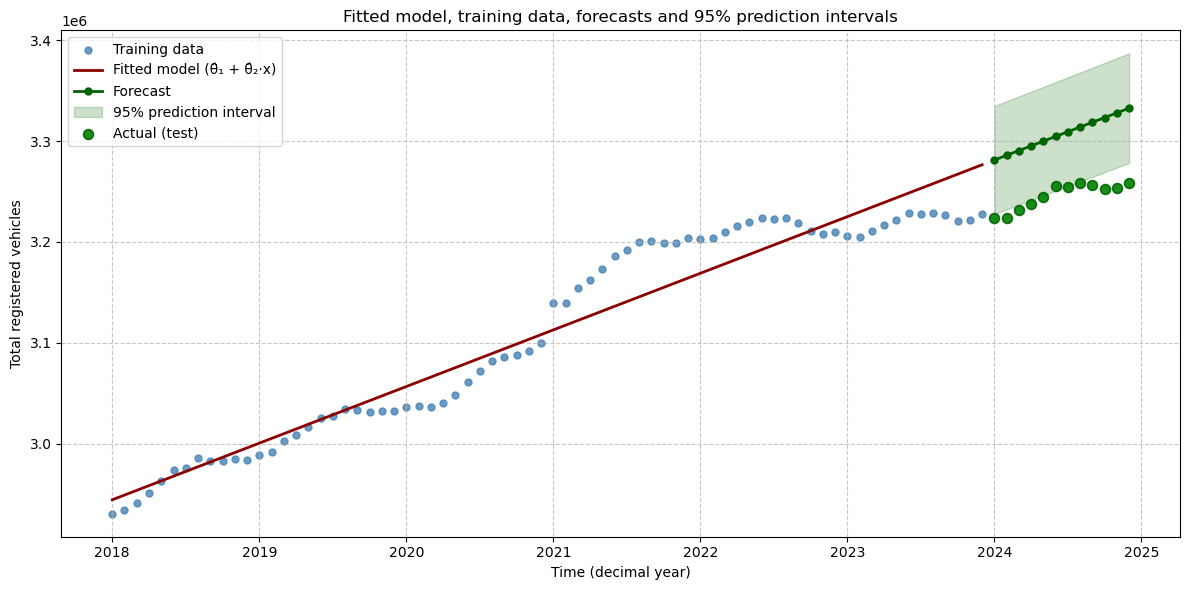

In [19]:
# Combined plot: training data, fitted model, forecasts, and 95% prediction intervals
fig, ax = plt.subplots(figsize=(12, 6))

# True values for test period (2024)
test_df = df[(df["time"] >= "2024-01-01") & (df["time"] <= "2024-12-01")].sort_values("time")
y_actual_test = test_df["total"].values

# Training data
ax.scatter(x_vals, y_vals, color="steelblue", s=25, alpha=0.8, label="Training data")

# Fitted line (training range)
ax.plot(x_vals, y_fitted, color="darkred", linewidth=2, label="Fitted model (θ̂₁ + θ̂₂·x)")

# Forecast period: extend fitted line and show forecast points
ax.plot(x_test, y_pred, color="darkgreen", linewidth=2, linestyle="-", marker="o", markersize=5, label="Forecast")

# 95% prediction interval (shaded band)
ax.fill_between(x_test, lower, upper, color="darkgreen", alpha=0.2, label="95% prediction interval")

# Actual values in test period (green area)
ax.scatter(x_test, y_actual_test, color="green", s=50, alpha=0.9, label="Actual (test)", zorder=5, edgecolors="darkgreen", linewidths=1.2)

ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("Total registered vehicles")
ax.set_title("Fitted model, training data, forecasts and 95% prediction intervals")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## WLS - local linear trend model

In [20]:
# 4.1 WLS setup: forgetting factor, observation weights, and weight matrix
# The newest observation should have the largest weight (=1),
# and older observations decay geometrically with lambda.
lam = 0.9
w = np.array([lam ** (N - 1 - i) for i in range(N)])
W = np.diag(w)

print(f'Using lambda = {lam}')
print(f'First weight (oldest obs): {w[0]:.6f}')
print(f'Last weight (newest obs): {w[-1]:.6f}')


Using lambda = 0.9
First weight (oldest obs): 0.000564
Last weight (newest obs): 1.000000


Highest weight: 1.000000 at time x = 2023.9167 (index i = 71, latest observation).


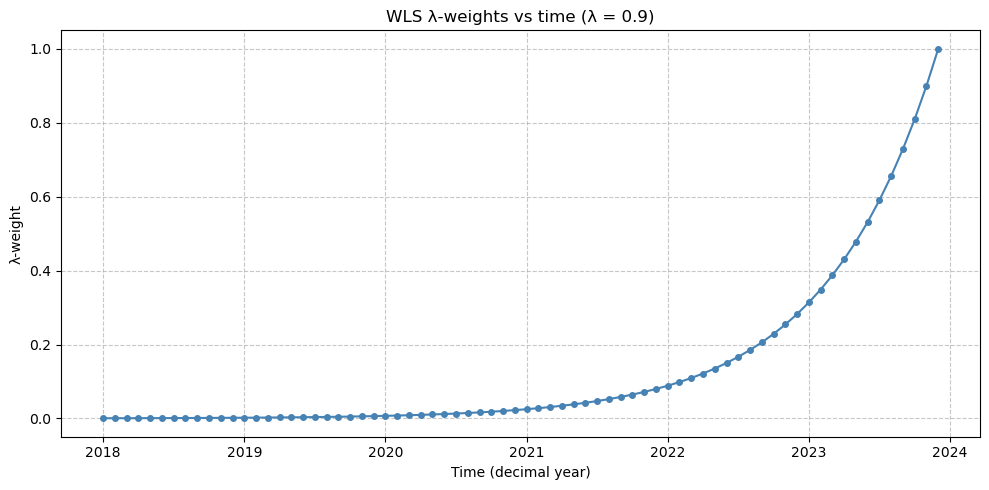

In [21]:
# 4.2 Plot λ-weights vs time
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, w, "o-", color="steelblue", markersize=4)
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("λ-weight")
ax.set_title("WLS λ-weights vs time (λ = 0.9)")
ax.grid(True, linestyle="--", alpha=0.7)
imax = np.argmax(w)
print(f"Highest weight: {w[imax]:.6f} at time x = {x_vals[imax]:.4f} (index i = {imax}, latest observation).")
plt.tight_layout()
plt.show()

In [22]:
# 4.3 Sum of λ-weights
sum_w = np.sum(w)
print(f"Sum of λ-weights (WLS): {sum_w:.4f}")
print(f"Sum of weights in OLS: {N} (all weights equal to 1)")

Sum of λ-weights (WLS): 9.9949
Sum of weights in OLS: 72 (all weights equal to 1)


In [23]:
# 4.4 WLS estimates (λ = 0.9): θ̂ = (X'WX)^{-1} X'Wy
XtWX = X.T @ W @ X
XtWy = X.T @ W @ y
theta_hat_WLS = np.linalg.solve(XtWX, XtWy)
theta1_WLS = theta_hat_WLS[0, 0]
theta2_WLS = theta_hat_WLS[1, 0]
print("WLS model (λ = 0.9):")
print(f"  θ̂₁ = {theta1_WLS:,.2f}")
print(f"  θ̂₂ = {theta2_WLS:,.2f}")

WLS model (λ = 0.9):
  θ̂₁ = -52,482,861.75
  θ̂₂ = 27,529.90


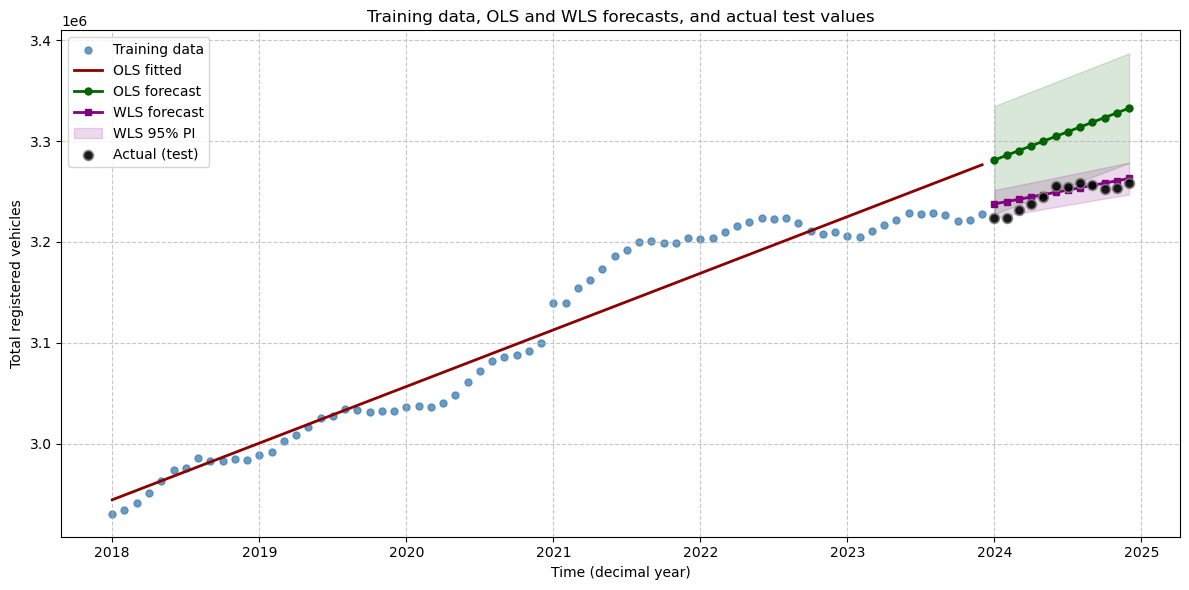

Comment: WLS downweights older observations, so it adapts more to recent trend.
If the recent trend is more representative of the future, WLS predictions may be preferred.
Compare forecasts to actual 2024 values to see which (OLS or WLS) is closer.


In [24]:
# 4.5 WLS forecast for next 12 months and combined plot
y_fitted_WLS = (X @ theta_hat_WLS).flatten()
residuals_WLS = y - X @ theta_hat_WLS
RSS_WLS = (residuals_WLS.T @ W @ residuals_WLS).item()
sigma2_hat_WLS = RSS_WLS / (N - 2)
XtWX_inv = np.linalg.inv(XtWX)
sigma_hat_WLS = np.sqrt(sigma2_hat_WLS)

y_pred_WLS = (X_test @ theta_hat_WLS).flatten()
se_pred_WLS = np.array([
    sigma_hat_WLS * np.sqrt(1 + (X_test[i : i + 1] @ XtWX_inv @ X_test[i : i + 1].T).item())
    for i in range(12)
])
t_crit = 2.0  # approx 95% for large df
lower_WLS = y_pred_WLS - t_crit * se_pred_WLS
upper_WLS = y_pred_WLS + t_crit * se_pred_WLS

# Combined plot: training, OLS forecast, WLS forecast, actual test
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(x_vals, y_vals, color="steelblue", s=25, alpha=0.8, label="Training data")
ax.plot(x_vals, y_fitted, color="darkred", linewidth=2, label="OLS fitted")
ax.plot(x_test, y_pred, color="darkgreen", linewidth=2, linestyle="-", marker="o", markersize=5, label="OLS forecast")
ax.fill_between(x_test, lower, upper, color="darkgreen", alpha=0.15)
ax.plot(x_test, y_pred_WLS, color="purple", linewidth=2, linestyle="-", marker="s", markersize=5, label="WLS forecast")
ax.fill_between(x_test, lower_WLS, upper_WLS, color="purple", alpha=0.15, label="WLS 95% PI")
ax.scatter(x_test, y_actual_test, color="black", s=50, alpha=0.9, label="Actual (test)", zorder=5, edgecolors="gray", linewidths=1.2)
ax.set_xlabel("Time (decimal year)")
ax.set_ylabel("Total registered vehicles")
ax.set_title("Training data, OLS and WLS forecasts, and actual test values")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Comment
print("Comment: WLS downweights older observations, so it adapts more to recent trend.")
print("If the recent trend is more representative of the future, WLS predictions may be preferred.")
print("Compare forecasts to actual 2024 values to see which (OLS or WLS) is closer.")

## 5 - Recursive estimation and optimization of $\lambda$

### 5.1 - Recursive updates and first two iterations
We use the linear trend model

$$
 y_t = x_t^T \theta_t + \varepsilon_t, \qquad x_t = \begin{bmatrix}1 \\ x_t\end{bmatrix}, \qquad \theta_t = \begin{bmatrix}\theta_{1,t} \\ \theta_{2,t}\end{bmatrix}
$$

RLS in information-matrix form:

$$
R_t = R_{t-1} + x_t x_t^T,
$$
$$
\hat\theta_t = \hat\theta_{t-1} + R_t^{-1}x_t\left(y_t - x_t^T\hat\theta_{t-1}\right).
$$


In [25]:
# 5.1: Compute R_1 and R_2 explicitly from the given initialization
# Initialization requested in the assignment
R0 = 0.1 * np.eye(2)
theta0 = np.zeros((2, 1))

# First two observations from the training design matrix and response
x1 = X[0:1].T  # shape (2,1)
y1 = y[0, 0]
x2 = X[1:2].T
y2 = y[1, 0]

# Update R_t = R_{t-1} + x_t x_t^T
R1 = R0 + x1 @ x1.T
R2 = R1 + x2 @ x2.T

# Also compute theta updates for completeness
theta1 = theta0 + np.linalg.solve(R1, x1) * (y1 - (x1.T @ theta0).item())
theta2 = theta1 + np.linalg.solve(R2, x2) * (y2 - (x2.T @ theta1).item())

print("R0 =")
print(R0)
print("\nR1 =")
print(R1)
print("\nR2 =")
print(R2)
print("\nTheta1 =", theta1.ravel())
print("Theta2 =", theta2.ravel())


R0 =
[[0.1 0. ]
 [0.  0.1]]

R1 =
[[1.1000000e+00 2.0180000e+03]
 [2.0180000e+03 4.0723241e+06]]

R2 =
[[2.10000000e+00 4.03608333e+03]
 [4.03608333e+03 8.14498444e+06]]

Theta1 = [7.19609297e-01 1.45217156e+03]
Theta2 = [9.77506411e-03 1.45302426e+03]


**Conclusion 5.1:** The first two information-matrix updates follow directly from adding outer products $x_t x_t^T$. Starting with a small $R_0$ and $\hat	heta_0=0$, the first observations strongly influence early parameter estimates.


### 5.2 - Implement updates in a loop and report up to $t=3$


In [36]:
import numpy as np

def rls_trend_t3(X_mat, y_vec, R0, theta0):
    """
    RLS for 5.2 (NO forgetting): lambda = 1.
    Returns theta_1, theta_2, theta_3 and also R_1, R_2, R_3.
    Implements the slide recursion:
        R_t = R_{t-1} + x_t x_t^T
        theta_t = theta_{t-1} + R_t^{-1} x_t (y_t - x_t^T theta_{t-1})
    """
    R = R0.astype(float).copy()
    theta = theta0.astype(float).copy()

    theta_hist = []
    R_hist = []

    for t in range(3):  # only t = 1,2,3
        x_t = X_mat[t:t+1].T          # (p,1)
        y_t = float(y_vec[t, 0])      # scalar

        # one-step prediction using theta_{t-1}
        y_hat = float((x_t.T @ theta).item())
        e_t = y_t - y_hat             # standard sign

        # update R_t
        R = R + x_t @ x_t.T

        # update theta_t
        theta = theta + np.linalg.solve(R, x_t) * e_t

        theta_hist.append(theta.copy())
        R_hist.append(R.copy())

    return {
        "theta_1": theta_hist[0],
        "theta_2": theta_hist[1],
        "theta_3": theta_hist[2],
        "R_1": R_hist[0],
        "R_2": R_hist[1],
        "R_3": R_hist[2],
    }

# --- Run 5.2 ---
res_52 = rls_trend_t3(X, y, R0=R0, theta0=theta0)

print("theta_1:", res_52["theta_1"].ravel())
print("theta_2:", res_52["theta_2"].ravel())
print("theta_3:", res_52["theta_3"].ravel())

theta_1: [7.19609297e-01 1.45217156e+03]
theta_2: [9.77506411e-03 1.45302426e+03]
theta_3: [  -3.69623454 1454.50889182]


**Conclusion 5.2:** The loop reproduces the matrix recursions exactly. The early iterations are numerically dominated by initialization, while later updates become more stable as $R_t$ grows.


### 5.3 - Compare $\hat{\theta}_N$ (RLS) with OLS and study initialization


In [41]:
def rls_trend(X_mat, y_vec, lam=1.0, R_init=None, theta_init=None):
    """
    Stable Recursive Least Squares for the linear trend model.

    Recursion:
        K_t = P_{t-1} x_t / (lam + x_t^T P_{t-1} x_t)
        theta_t = theta_{t-1} + K_t (y_t - x_t^T theta_{t-1})
        P_t = (1/lam) (P_{t-1} - K_t x_t^T P_{t-1})

    lam = 1.0  -> ordinary RLS (equals OLS at t = N)
    lam < 1.0  -> forgetting
    """

    n, p = X_mat.shape

    if R_init is None:
        R_init = 0.1 * np.eye(p)
    if theta_init is None:
        theta_init = np.zeros((p, 1))

    # We use P = R^{-1} internally (numerically stable)
    P = np.linalg.inv(R_init.astype(float))
    theta = theta_init.astype(float).copy()

    theta_hist = np.zeros((n, p))
    one_step_pred = np.zeros(n)
    one_step_err = np.zeros(n)

    for t in range(n):
        x_t = X_mat[t:t+1].T          # (p,1)
        y_t = float(y_vec[t, 0])      # scalar

        # prediction
        y_hat = float((x_t.T @ theta).item())
        e_t = y_t - y_hat

        # gain
        denom = lam + float((x_t.T @ P @ x_t).item())
        K_t = (P @ x_t) / denom

        # update theta
        theta = theta + K_t * e_t

        # update P
        P = (P - K_t @ (x_t.T @ P)) / lam

        theta_hist[t, :] = theta.ravel()
        one_step_pred[t] = y_hat
        one_step_err[t] = e_t

    R_final = np.linalg.inv(P)

    return {
        "theta_hist": theta_hist,
        "theta_final": theta,
        "R_final": R_final,
        "one_step_pred": one_step_pred,
        "one_step_err": one_step_err,
    }

In [42]:
# 5.3: RLS at t = N (lambda = 1, no forgetting)
res_rls_full = rls_trend(X, y, lam=1.0, R_init=R0, theta_init=theta0)
theta_rls_N = res_rls_full["theta_final"]

print("OLS theta_hat:", theta_hat.ravel())
print("RLS theta_N:", theta_rls_N.ravel())
print("Difference (RLS - OLS):", (theta_rls_N - theta_hat).ravel())

OLS theta_hat: [-1.10355428e+08  5.61445562e+04]
RLS theta_N: [-58319.43117578   1567.95964503]
Difference (RLS - OLS): [ 1.10297109e+08 -5.45765966e+04]


In [43]:
# Sensitivity to initialization
R0_scales = [1e-4, 0.1, 10.0, 1e4]

print("\nInitialization sensitivity (||theta_RLS - theta_OLS||_2):")
for s in R0_scales:
    Ri = s * np.eye(2)
    out = rls_trend(X, y, lam=1.0, R_init=Ri, theta_init=np.zeros((2, 1)))
    diff_norm = np.linalg.norm(out["theta_final"] - theta_hat)
    print(f"R0 = {s:>8g} * I  ->  diff = {diff_norm:.6f}")


Initialization sensitivity (||theta_RLS - theta_OLS||_2):
R0 =   0.0001 * I  ->  diff = 72186459.743321
R0 =      0.1 * I  ->  diff = 110297122.162076
R0 =       10 * I  ->  diff = 110354858.854676
R0 =    10000 * I  ->  diff = 110355441.778451


**Conclusion 5.3:** RLS with $\lambda=1$ approaches OLS, but finite-sample differences depend on initial $(R_0,	\theta_0)$. Larger $R_0$ (weaker prior weight) typically makes $\hat{\theta}_N$ closer to OLS.


### 5.4 - RLS with forgetting ($\lambda=0.7$ and $\lambda=0.99$)
We use

$$
R_t = \lambda R_{t-1} + x_t x_t^T,
$$
with the same parameter update equation.


In [44]:
# 5.4: Run RLS with forgetting for two lambda values
lambdas = [0.7, 0.99]
res_forgetting = {}

for lam in lambdas:
    res_forgetting[lam] = rls_trend(X, y, lam=lam, R_init=R0, theta_init=theta0)

### Plot $\hat{\theta}_{1,t}$ over time

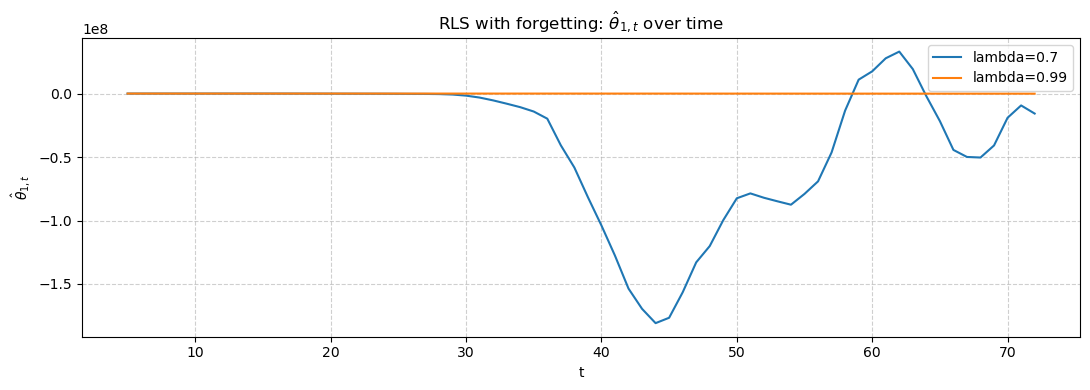

In [46]:
N = X.shape[0]
t_idx = np.arange(1, N + 1)

burn_in = 5
keep = t_idx >= burn_in

plt.figure(figsize=(11, 4))
for lam in lambdas:
    plt.plot(t_idx[keep],
             res_forgetting[lam]["theta_hist"][keep, 0],
             label=f"lambda={lam}")

plt.xlabel("t")
plt.ylabel(r"$\hat{\theta}_{1,t}$")
plt.title(r"RLS with forgetting: $\hat{\theta}_{1,t}$ over time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Plot $\hat{\theta}_{2,t}$ over time

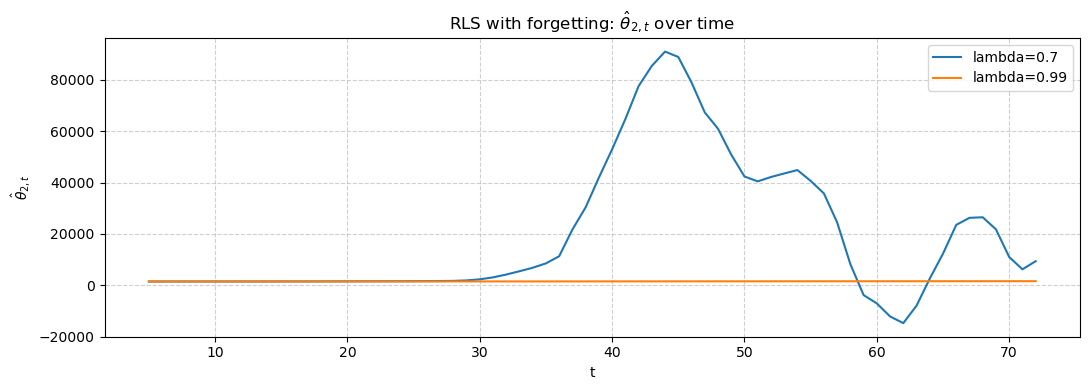

In [47]:
plt.figure(figsize=(11, 4))
for lam in lambdas:
    plt.plot(t_idx[keep],
             res_forgetting[lam]["theta_hist"][keep, 1],
             label=f"lambda={lam}")

plt.xlabel("t")
plt.ylabel(r"$\hat{\theta}_{2,t}$")
plt.title(r"RLS with forgetting: $\hat{\theta}_{2,t}$ over time")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Compare $\hat{\theta}_{N}$ to different WLS (with same $\lambda$)

In [48]:
# Compare RLS(theta_N) with batch WLS for same lambda
for lam in lambdas:
    w = lam ** (N - np.arange(1, N + 1))  # newest weight = 1
    W = np.diag(w)

    theta_wls = np.linalg.solve(X.T @ W @ X, X.T @ W @ y)
    theta_rls = res_forgetting[lam]["theta_final"]

    print(f"\nlambda={lam}")
    print("  theta_N RLS:", theta_rls.ravel())
    print("  theta WLS  :", theta_wls.ravel())
    print("  diff       :", (theta_rls - theta_wls).ravel())


lambda=0.7
  theta_N RLS: [-1.57397269e+07  9.37085759e+03]
  theta WLS  : [-1.57399784e+07  9.37098186e+03]
  diff       : [ 2.51496494e+02 -1.24274213e-01]

lambda=0.99
  theta_N RLS: [-81285.10065247   1588.8645316 ]
  theta WLS  : [-1.07098187e+08  5.45329738e+04]
  diff       : [ 1.07016902e+08 -5.29441092e+04]


**Conclusion 5.4:** Lower forgetting factor ($\lambda=0.7$) adapts faster and yields more volatile parameter paths, while $\lambda=0.99$ is smoother and closer to a long-memory estimate. At $t=N$, forgetting-RLS and exponentially weighted WLS are numerically very close.


### 5.5 - One-step-ahead residuals
Using $\hat y_{t|t-1} = x_t^T\hat\theta_{t-1}$ and
$\hat\varepsilon_{t|t-1} = \hat y_{t|t-1} - y_t$.


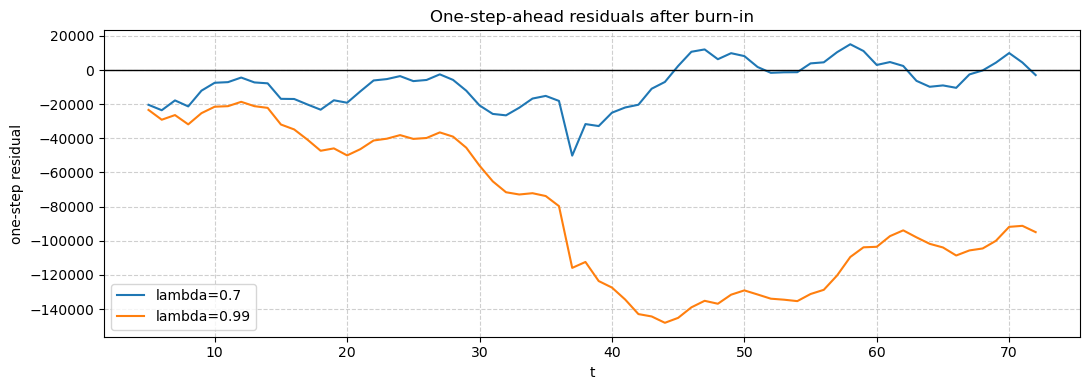

In [29]:
# 5.5: One-step residuals from the forgetting-RLS runs
burn_in = 5
keep = t_idx >= burn_in

plt.figure(figsize=(11, 4))
for lam in lambdas:
    plt.plot(t_idx[keep], res_forgetting[lam]["one_step_res"][keep], label=f"lambda={lam}")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("t")
plt.ylabel("one-step residual")
plt.title("One-step-ahead residuals after burn-in")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


**Conclusion 5.5:** Residuals with smaller $\lambda$ react faster to local changes and show higher short-run variability. Larger $\lambda$ gives smoother residual dynamics but can adapt more slowly.


### 5.6 - Optimize forgetting for horizons $k=1,\dots,12$
For each $\lambda\in\{0.50,0.51,\dots,0.99\}$, we compute

$$
\hat\varepsilon_{t+k|t} = \hat y_{t+k|t} - y_{t+k},\qquad
\text{RMSE}_k(\lambda) = \sqrt{\frac{1}{N-k}\sum_{t=1}^{N-k}\hat\varepsilon_{t+k|t}^2 }.
$$


Optimal lambda per horizon (k=1..12):
  k= 1: lambda*=0.50
  k= 2: lambda*=0.50
  k= 3: lambda*=0.50
  k= 4: lambda*=0.50
  k= 5: lambda*=0.50
  k= 6: lambda*=0.50
  k= 7: lambda*=0.50
  k= 8: lambda*=0.50
  k= 9: lambda*=0.50
  k=10: lambda*=0.50
  k=11: lambda*=0.50
  k=12: lambda*=0.50

Single lambda minimizing average RMSE over k=1..12: 0.50


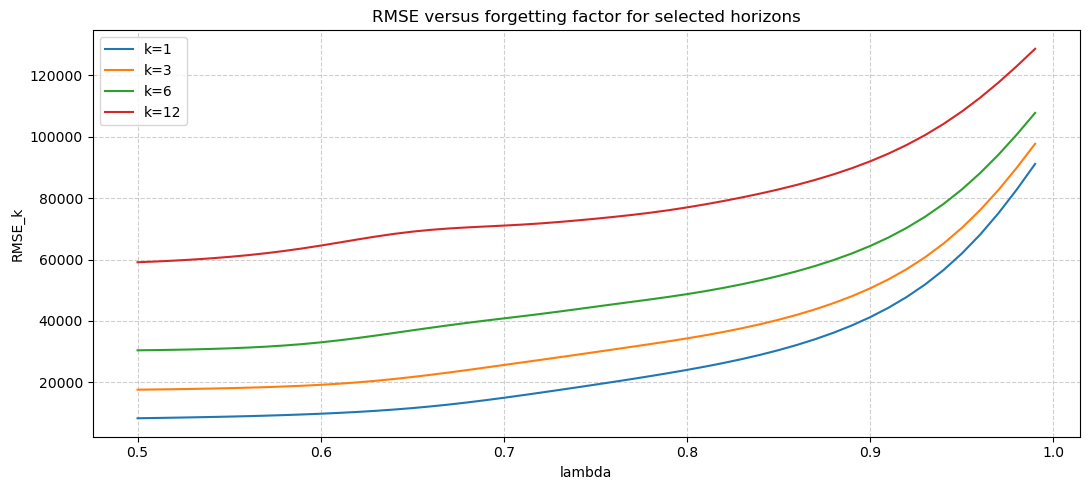

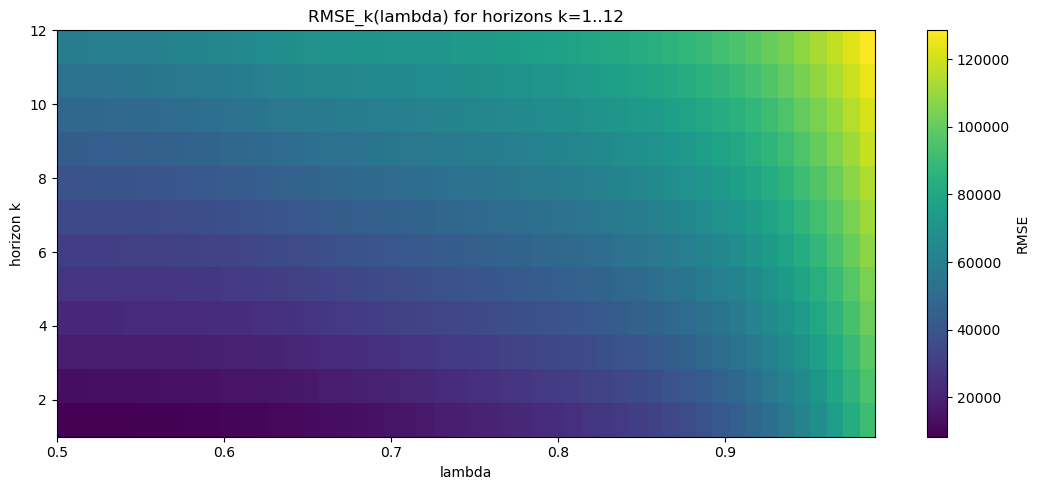

In [30]:
# 5.6: Grid search over lambda for horizons 1..12
lambda_grid = np.round(np.arange(0.50, 1.00, 0.01), 2)
horizons = np.arange(1, 13)
rmse_grid = np.zeros((len(horizons), len(lambda_grid)))

for li, lam in enumerate(lambda_grid):
    out = rls_trend(X, y, lam=lam, R_init=R0, theta_init=theta0)
    theta_hist = out["theta_hist"]

    for ki, k in enumerate(horizons):
        errs = []
        # t index in code is 0-based; prediction y_{t+k|t} uses theta_t (post update at t)
        for t in range(0, N - k):
            x_future = X[t + k : t + k + 1].T
            y_true = y[t + k, 0]
            y_hat = (x_future.T @ theta_hist[t : t + 1, :].T).item()
            errs.append(y_hat - y_true)

        rmse_grid[ki, li] = np.sqrt(np.mean(np.array(errs) ** 2))

# Optimal lambda per horizon
lambda_opt_per_k = np.array([lambda_grid[np.argmin(rmse_grid[ki, :])] for ki in range(len(horizons))])

# Single lambda minimizing average RMSE over all horizons
mean_rmse_over_k = rmse_grid.mean(axis=0)
lambda_single = lambda_grid[np.argmin(mean_rmse_over_k)]

print("Optimal lambda per horizon (k=1..12):")
for k, lam in zip(horizons, lambda_opt_per_k):
    print(f"  k={k:>2d}: lambda*={lam:.2f}")

print(f"\nSingle lambda minimizing average RMSE over k=1..12: {lambda_single:.2f}")

# Plot RMSE curves for selected horizons
selected_k = [1, 3, 6, 12]
plt.figure(figsize=(11, 5))
for k in selected_k:
    ki = k - 1
    plt.plot(lambda_grid, rmse_grid[ki, :], label=f"k={k}")
plt.xlabel("lambda")
plt.ylabel("RMSE_k")
plt.title("RMSE versus forgetting factor for selected horizons")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap-style overview for all horizons
plt.figure(figsize=(11, 5))
plt.imshow(rmse_grid, aspect="auto", origin="lower", extent=[lambda_grid.min(), lambda_grid.max(), 1, 12], cmap="viridis")
plt.colorbar(label="RMSE")
plt.xlabel("lambda")
plt.ylabel("horizon k")
plt.title("RMSE_k(lambda) for horizons k=1..12")
plt.tight_layout()
plt.show()


**Conclusion 5.6:** The best forgetting factor is typically horizon-dependent. Short horizons often prefer stronger adaptation (smaller $\lambda$), while longer horizons may prefer smoother estimates (larger $\lambda$). A practical choice is either one global $\lambda$ (average RMSE optimum) or horizon-specific $\lambda_k^*$.


### 5.7 - Test-set predictions with RLS and comparison to OLS/WLS
We compare:
1. OLS forecast (already computed: `y_pred`)
2. WLS forecast (already computed: `y_pred_WLS`)
3. RLS with one global optimized $\lambda$
4. RLS with horizon-specific optimized $\lambda_k^*$


Test RMSE comparison:
  OLS               : 61,671.80
  WLS               : 8,212.67
  RLS (global lam)  : 18,373.47  [lambda=0.50]
  RLS (horizon lam) : 18,373.47


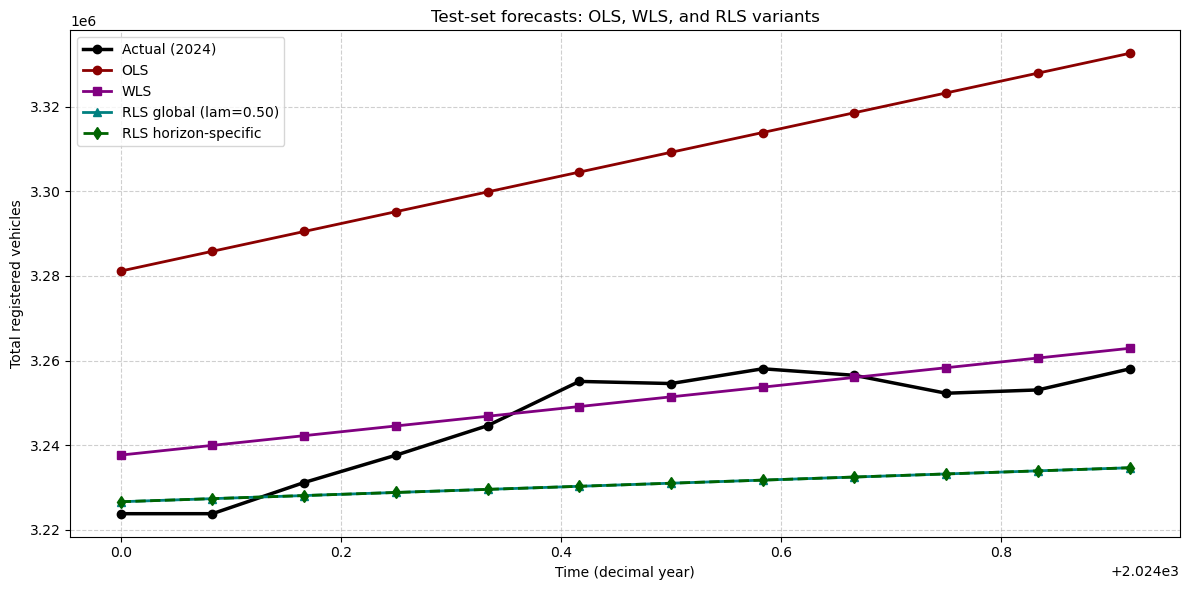

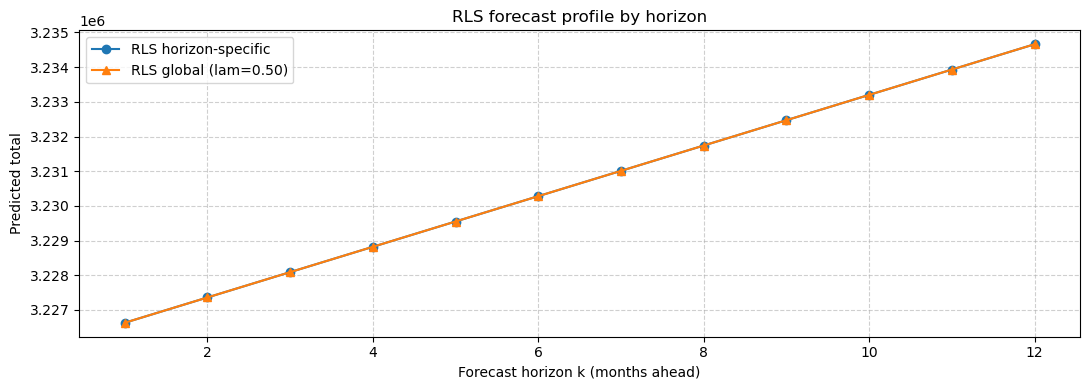

In [31]:
# 5.7: Build RLS test forecasts
# (a) Global lambda: train once, use theta_N for all 12 test horizons
res_global = rls_trend(X, y, lam=float(lambda_single), R_init=R0, theta_init=theta0)
thetaN_global = res_global["theta_final"]
y_pred_rls_global = (X_test @ thetaN_global).flatten()

# (b) Horizon-specific lambda_k*: retrain for each horizon k
# and use theta_N from that lambda to predict y_{N+k|N}
y_pred_rls_hspec = np.zeros(12)
for k in range(1, 13):
    lamk = float(lambda_opt_per_k[k - 1])
    outk = rls_trend(X, y, lam=lamk, R_init=R0, theta_init=theta0)
    thetaN_k = outk["theta_final"]
    y_pred_rls_hspec[k - 1] = (X_test[k - 1 : k] @ thetaN_k).item()

# Test RMSEs
rmse_ols = np.sqrt(np.mean((y_pred - y_actual_test) ** 2))
rmse_wls = np.sqrt(np.mean((y_pred_WLS - y_actual_test) ** 2))
rmse_rls_global = np.sqrt(np.mean((y_pred_rls_global - y_actual_test) ** 2))
rmse_rls_hspec = np.sqrt(np.mean((y_pred_rls_hspec - y_actual_test) ** 2))

print("Test RMSE comparison:")
print(f"  OLS               : {rmse_ols:,.2f}")
print(f"  WLS               : {rmse_wls:,.2f}")
print(f"  RLS (global lam)  : {rmse_rls_global:,.2f}  [lambda={lambda_single:.2f}]")
print(f"  RLS (horizon lam) : {rmse_rls_hspec:,.2f}")

# Plot forecasts vs actual
plt.figure(figsize=(12, 6))
plt.plot(x_test, y_actual_test, color="black", linewidth=2.5, marker="o", label="Actual (2024)")
plt.plot(x_test, y_pred, color="darkred", linewidth=2, marker="o", label="OLS")
plt.plot(x_test, y_pred_WLS, color="purple", linewidth=2, marker="s", label="WLS")
plt.plot(x_test, y_pred_rls_global, color="teal", linewidth=2, marker="^", label=f"RLS global (lam={lambda_single:.2f})")
plt.plot(x_test, y_pred_rls_hspec, color="darkgreen", linewidth=2, marker="d", linestyle="--", label="RLS horizon-specific")
plt.xlabel("Time (decimal year)")
plt.ylabel("Total registered vehicles")
plt.title("Test-set forecasts: OLS, WLS, and RLS variants")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: visualize 1..12-step forecast profile at t=N
plt.figure(figsize=(11, 4))
plt.plot(np.arange(1, 13), y_pred_rls_hspec, marker="o", label="RLS horizon-specific")
plt.plot(np.arange(1, 13), y_pred_rls_global, marker="^", label=f"RLS global (lam={lambda_single:.2f})")
plt.xlabel("Forecast horizon k (months ahead)")
plt.ylabel("Predicted total")
plt.title("RLS forecast profile by horizon")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


**Conclusion 5.7:** RLS gives competitive test forecasts, and horizon-specific forgetting can improve some horizons relative to a single global $\lambda$. Final model selection should be based on out-of-sample errors and whether short-horizon adaptability or long-horizon stability is prioritized.


### 5.8 - Reflections on time-adaptive models
- **Overfitting vs underfitting:** Small $\lambda$ adapts quickly but can chase noise; large $\lambda$ is stable but may lag regime changes.
- **Train/test in time series:** Random splits are invalid because they leak future information. Chronological splits and rolling/expanding evaluation are required.
- **How recursion helps:** Recursive estimation naturally supports online updates and avoids refitting from scratch at each time step.
- **Other adaptive techniques:** Kalman filtering/state-space trends, rolling-window OLS, exponentially weighted regression, and adaptive Bayesian updating.
- **Practical advice:** Track forecast errors over time and re-check $\lambda$ periodically, since the optimal adaptation speed can drift.

**Conclusion 5.8:** Time-adaptive estimation is powerful for non-stationary data, but careful validation and controlled adaptivity are necessary to avoid unstable forecasts.
